<a href="https://colab.research.google.com/github/mallapuabhiraj/Credit-Card-Fraud-Detection/blob/main/CatBoost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install catboost optuna --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 21.1 MB/s eta 0:00:00


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import warnings
from sklearn.metrics import precision_recall_curve, accuracy_score,precision_score, recall_score, roc_auc_score, confusion_matrix, classification_report, average_precision_score

In [4]:
train = pd.read_csv('/content/drive/MyDrive/fraudTrain.csv')
test = pd.read_csv('/content/drive/MyDrive/fraudTest.csv')

In [ ]:
# Sort by transaction time first (CRITICAL for time-based split)
train = train.sort_values('trans_date_trans_time').reset_index(drop=True)

X = train.drop('is_fraud', axis=1)
y = train['is_fraud']

# Time-based split
split_idx = int(len(train) * 0.8)
X_train = X.iloc[:split_idx]
X_val = X.iloc[split_idx:]
y_train = y.iloc[:split_idx]
y_val = y.iloc[split_idx:]

# Test data
X_test = test.drop('is_fraud', axis=1)
y_test = test['is_fraud']

scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])
print(f"scale_pos_weight(y_train): {scale_pos_weight}")
scale_pos_weight = len(y_val[y_val == 0]) / len(y_val[y_val == 1])
print(f"scale_pos_weight(y_val): {scale_pos_weight}")
scale_pos_weight = len(y_test[y_test == 0]) / len(y_test[y_test == 1])
print(f"scale_pos_weight(y_test): {scale_pos_weight}")
print(f"Train Shape: {X_train.shape}, {y_train.shape}")
print(f"Validation Shape: {X_val.shape}")
print(f"Test Shape: {X_test.shape}")

scale_pos_weight(y_train): 176.9507848960543
scale_pos_weight(y_val): 161.31811145510835
scale_pos_weight(y_test): 258.07645687645686
Train Shape: (838860, 22), (838860,)
Validation Shape: (209715, 22)
Test Shape: (555719, 22)


In [ ]:
def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371.0
    # Use np.radians instead of math.radians for array support
    lat1_rad, lon1_rad = np.radians(lat1), np.radians(lon1)
    lat2_rad, lon2_rad = np.radians(lat2), np.radians(lon2)
    dlon = lon2_rad - lon1_rad
    dlat = lat2_rad - lat1_rad
    a = np.sin(dlat / 2)**2 + np.cos(lat1_rad) * np.cos(lat2_rad) * np.sin(dlon / 2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    # Use np.round instead of round for array support
    return np.round(R * c)

def preprocess(df):
    df = df.copy()

    # 1. Parsing dates to DateTime format
    df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'], format='mixed')
    df['dob'] = pd.to_datetime(df['dob'], format='mixed', errors='coerce')

    # 2. Calculating age and distance features
    df['age'] = ((df['trans_date_trans_time'] - df['dob']).dt.days // 365).clip(18, 100).astype(int)
    df['distance_km'] = haversine_distance(
        df['lat'].values, df['long'].values,
        df['merch_lat'].values, df['merch_long'].values
    )

    df['prev_merch_lat'] = df.groupby('cc_num')['merch_lat'].shift(1)
    df['prev_merch_long'] = df.groupby('cc_num')['merch_long'].shift(1)
    df['dist_from_last_trans'] = haversine_distance(
        df['merch_lat'].values, df['merch_long'].values,
        df['prev_merch_lat'].fillna(df['merch_lat']).values,
        df['prev_merch_long'].fillna(df['merch_long']).values
    )

    # Velocity features
    df['trans_today'] = df.groupby(['cc_num', df['trans_date_trans_time'].dt.date]).cumcount() + 1
    df['time_since_last_min'] = (df.groupby('cc_num')['trans_date_trans_time'].diff().dt.total_seconds() / 60).fillna(1440)
    df['is_rapid_succession'] = (df['time_since_last_min'] < 5).astype(int)
    df['high_daily_activity'] = (df['trans_today'] > 3).astype(int)

    # Time since last transaction
    df['time_since_last_trans_hr'] = (df.groupby('cc_num')['trans_date_trans_time'].diff().dt.total_seconds() // 3600).fillna(24)
    df["km_per_hour"] = df["distance_km"] / (df["time_since_last_trans_hr"] + 1)
    df["is_impossible_travel"] = (df["km_per_hour"] > 500).astype(int)

    # Time and Amount features
    df['hour'] = df['trans_date_trans_time'].dt.hour
    df['day_of_week'] = df['trans_date_trans_time'].dt.dayofweek
    df['month'] = df['trans_date_trans_time'].dt.month
    df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)
    df['is_night'] = ((df['hour'] >= 21) | (df['hour'] <= 6)).astype(int)
    df['is_midnight'] = df['hour'].between(0,3).astype(int)
    df['is_high_amount'] = (df['amt'] > 50).astype(int)  # Fixed threshold
    df['is_very_high_amount'] = (df['amt'] > 100).astype(int)  # Fixed threshold

    # Location and Age grouping
    df['is_local'] = (df['distance_km'] < 10).astype(int)
    df['is_short_travel'] = ((df['distance_km'] >= 10) & (df['distance_km'] < 100)).astype(int)
    df['is_medium_travel'] = ((df['distance_km'] >= 100) & (df['distance_km'] < 500)).astype(int)
    df['is_long_travel'] = (df['distance_km'] >= 500).astype(int)
    df['age_group'] = pd.cut(df['age'], bins=[0, 25, 35, 50, 65, 100],
       labels=['young', 'young_adult', 'middle', 'senior', 'elderly'])

    # Transaction count per card
    df['trans_num_per_card'] = df.groupby('cc_num').cumcount() + 1
    df["user_night_rate"] = (df.groupby("cc_num")["is_night"]
      .transform(lambda x: x.expanding().mean().shift(1).fillna(0))
       )
    df["night_anomaly"] = ((df["is_night"] == 1) & (df["user_night_rate"] < 0.1)).astype(int)

    # Encoding
    df['amt_log'] = np.log1p(df['amt'])
    df['gender'] = df['gender'].map({'M': 1, 'F': 0}).fillna(0).astype(int)

    # Anomaly features
    df['amt_mean_card'] = df.groupby('cc_num')['amt'].expanding().mean().reset_index(0, drop=True)
    df['amt_std_card'] = df.groupby('cc_num')['amt'].expanding().std().reset_index(0, drop=True).fillna(1)
    df['amt_max_card'] = df.groupby('cc_num')['amt'].expanding().max().reset_index(0, drop=True)
    df['amt_zscore'] = (df['amt'] - df['amt_mean_card']) / (df['amt_std_card'] + 0.01)
    df['amt_ratio_to_max'] = df['amt'] / (df['amt_max_card'] + 1)
    df['unusual_amount'] = (df['amt_zscore'] > 2).astype(int)
    df['very_unusual_amount'] = (df['amt_zscore'] > 3).astype(int)

    df['distance_mean_card'] = df.groupby('cc_num')['distance_km'].expanding().mean().reset_index(0, drop=True)
    df['distance_std_card'] = df.groupby('cc_num')['distance_km'].expanding().std().reset_index(0, drop=True).fillna(1)
    df['distance_zscore'] = (df['distance_km'] - df['distance_mean_card']) / (df['distance_std_card'] + 0.01)
    df['unusual_location'] = (df['distance_zscore'] > 2).astype(int)

    df['prev_category'] = df.groupby('cc_num')['category'].shift(1)
    df['category_switch'] = (df['category'] != df['prev_category']).fillna(0).astype(int)

    df['merchant_first_use'] = (df.groupby(['cc_num', 'merchant']).cumcount() == 0).astype(int)
    df['city_first_use'] = (df.groupby(['cc_num', 'city']).cumcount() == 0).astype(int)
    df['category_first_use'] = (df.groupby(['cc_num', 'category']).cumcount() == 0).astype(int)

    # Interaction features
    df['high_amt_night'] = ((df['amt'] > 100) & (df['is_night'] == 1)).astype(int)
    df['high_amt_far'] = ((df['amt'] > 100) & (df['distance_km'] > 100)).astype(int)
    df['new_merchant_high_amt'] = (df['merchant_first_use'] * (df['amt'] > 100)).astype(int)
    df['rapid_high_amt'] = ((df['is_rapid_succession'] == 1) & (df['amt'] > 100)).astype(int)
    df['weekend_night'] = (df['is_weekend'] & df['is_night']).astype(int)
    df['amt_distance_product'] = np.log1p(df['amt'] * df['distance_km'])

    # Amount unusual for this category
    df['category_amt_mean'] = df.groupby('category')['amt'].transform(
      lambda x: x.expanding().mean().shift(1).fillna(x.mean())
       )
    df['category_amt_std'] = df.groupby('category')['amt'].transform(
      lambda x: x.expanding().std().shift(1).fillna(x.std())
       )
    df['amt_zscore_category'] = (df['amt'] - df['category_amt_mean']) / (df['category_amt_std'] + 0.01)

    # Dormant card reactivation — silent card suddenly active with high amount
    df['is_dormant_reactivation'] = (
    (df['time_since_last_min'] > 10080) &  # >7 days gap
    (df['amt'] > df['amt_mean_card'])
    ).astype(int)

    df['new_category_high_amt'] = (
      (df['category_first_use'] == 1) & (df['amt'] > 100)
        ).astype(int)
    df['new_city_high_amt'] = (
      (df['city_first_use'] == 1) & (df['amt'] > 100)
        ).astype(int)
    # Add this in preprocess after pd.cut
    df['age_group'] = df['age_group'].astype(str)

    # Drop columns
    drop_cols = ['category_amt_mean', 'category_amt_std','merchant','city','Unnamed: 0', 'first', 'last', 'street', 'trans_num', 'cc_num', 'category_amt_std',
                 'trans_date_trans_time', 'lat', 'long', 'merch_lat', 'merch_long', 'category_amt_mean',
                 'unix_time', 'dob', 'prev_merch_lat', 'prev_merch_long', 'prev_category']
    df = df.drop(columns=[c for c in drop_cols if c in df.columns])

    # Reset index
    df = df.reset_index(drop=True)

    return df
from sklearn.base import BaseEstimator, TransformerMixin

class Preprocess(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return preprocess(X)

In [ ]:
from sklearn.pipeline import Pipeline
from catboost import CatBoostClassifier, Pool

# Preprocess train and val separately outside pipeline
preprocess_pipe = Pipeline([('preprocess', Preprocess())])
cat_cols = ['job','age_group', 'category', 'state']

X_train_proc = preprocess_pipe.fit_transform(X_train, y_train)
X_val_proc   = preprocess_pipe.transform(X_val)

# Create Pools
train_pool = Pool(X_train_proc, y_train, cat_features=cat_cols)
val_pool   = Pool(X_val_proc,   y_val,   cat_features=cat_cols)

# Train CatBoost directly (not through pipeline)
cb_model = CatBoostClassifier(
    task_type=   'GPU',
    iterations=600,
    depth=10,
    learning_rate= 0.037478113360623636,
  l2_leaf_reg= 7.976195410250031,
  scale_pos_weight= 243.9498941564189,
  bagging_temperature= 0.8948273504276488,
  random_strength= 1.9947499470277128,
  border_count=240,
    cat_features=cat_cols,
    eval_metric='PRAUC',
    random_seed=42,
    verbose=100
)

cb_model.fit(
    train_pool,
    eval_set=val_pool,
    early_stopping_rounds=50,
)

# Evaluate on val
y_proba = cb_model.predict_proba(X_val_proc)[:, 1]
y_pred  = cb_model.predict(X_val_proc)

print(f"PR-AUC:  {average_precision_score(y_val, y_proba):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_val, y_proba):.4f}")
print(confusion_matrix(y_val, y_pred))
print(classification_report(y_val, y_pred, zero_division=0))

# Evaluate on test
X_test_proc = preprocess_pipe.transform(X_test)
test_pool = Pool(X_test_proc, cat_features=cat_cols)

y_test_proba = cb_model.predict_proba(test_pool)[:, 1]
print(f"Test PR-AUC: {average_precision_score(y_test, y_test_proba):.4f}")

/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
Default metric period is 5 because PRAUC is/are not implemented for GPU
Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time


0:	learn: 0.9932768	test: 0.9938620	best: 0.9938620 (0)	total: 269ms	remaining: 2m 41s
100:	learn: 0.9997385	test: 0.9991236	best: 0.9991245 (99)	total: 23.6s	remaining: 1m 56s
200:	learn: 0.9999495	test: 0.9993666	best: 0.9993666 (200)	total: 48.1s	remaining: 1m 35s
300:	learn: 0.9999883	test: 0.9993982	best: 0.9994120 (281)	total: 1m 11s	remaining: 1m 11s
bestTest = 0.9994120189
bestIteration = 281
Shrink model to first 282 iterations.
PR-AUC:  0.9561
ROC-AUC: 0.9991
[[207536    887]
 [    44   1248]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    208423
           1       0.58      0.97      0.73      1292

    accuracy                           1.00    209715
   macro avg       0.79      0.98      0.86    209715
weighted avg       1.00      1.00      1.00    209715



/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


Test PR-AUC: 0.9320


Starting CatBoost tuning...


  0%|          | 0/10 [00:00<?, ?it/s]


Best Val PR-AUC: 0.9418

Best Parameters:
  learning_rate: 0.037478113360623636
  depth: 10
  l2_leaf_reg: 7.976195410250031
  scale_pos_weight: 243.9498941564189
  bagging_temperature: 0.8948273504276488
  random_strength: 1.9947499470277128
  border_count: 240

PARAMETER IMPORTANCE
  l2_leaf_reg: 0.5705
  scale_pos_weight: 0.1535
  border_count: 0.0946
  bagging_temperature: 0.0834
  depth: 0.0653
  learning_rate: 0.0228
  random_strength: 0.0099

Training final tuned model...


Default metric period is 5 because PRAUC is/are not implemented for GPU
Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time


0:	learn: 0.9932768	test: 0.9938620	best: 0.9938620 (0)	total: 273ms	remaining: 2m 43s
100:	learn: 0.9997778	test: 0.9991770	best: 0.9991892 (95)	total: 27.9s	remaining: 2m 18s
200:	learn: 0.9999565	test: 0.9993576	best: 0.9993576 (200)	total: 56s	remaining: 1m 51s
300:	learn: 0.9999892	test: 0.9993858	best: 0.9993858 (300)	total: 1m 24s	remaining: 1m 24s
bestTest = 0.9994092156
bestIteration = 319
Shrink model to first 320 iterations.

Tuned Val PR-AUC:  0.9567
Tuned Val ROC-AUC: 0.9991
[[207778    645]
 [    55   1237]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    208423
           1       0.66      0.96      0.78      1292

    accuracy                           1.00    209715
   macro avg       0.83      0.98      0.89    209715
weighted avg       1.00      1.00      1.00    209715


Tuned Test PR-AUC: 0.9284
Tuned Test ROC-AUC: 0.9986
[[552005   1569]
 [   124   2021]]
              precision    recall  f1-score   support

 

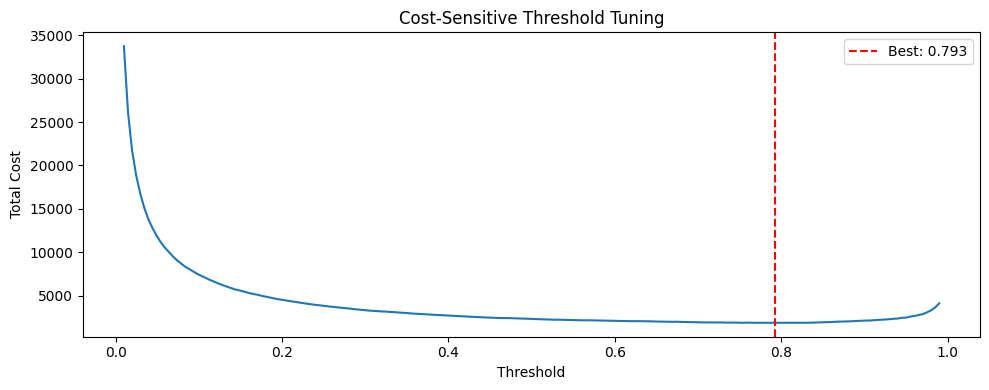

In [ ]:
import optuna
from optuna.samplers import TPESampler
from catboost import CatBoostClassifier
from sklearn.metrics import average_precision_score

optuna.logging.set_verbosity(optuna.logging.WARNING)

def cb_objective(trial):
    params = {
        'iterations':          600,  # fixed — early stopping handles optimal count
        'learning_rate':       trial.suggest_float('learning_rate', 0.03, 0.1, log=True),
        'depth':               trial.suggest_int('depth', 6, 10),
        'l2_leaf_reg':         trial.suggest_float('l2_leaf_reg', 1, 10),
        'scale_pos_weight':    trial.suggest_float('scale_pos_weight', 150, 250),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0, 1),
        'random_strength':     trial.suggest_float('random_strength', 0.5, 3),
        'border_count':        trial.suggest_int('border_count', 64, 255),
        'cat_features':        cat_cols,
        'eval_metric':         'Logloss',
        'task_type':           'GPU',   # remove if no GPU
        'random_seed':         42,
        'verbose':             0,
    }

    model = CatBoostClassifier(**params)
    model.fit(
        train_pool,
        eval_set=val_pool,
        early_stopping_rounds=50,
        verbose=False,
    )

    y_proba = model.predict_proba(X_val_proc)[:, 1]
    return average_precision_score(y_val, y_proba)


print("Starting CatBoost tuning...")
cb_study = optuna.create_study(
    direction='maximize',
    sampler=TPESampler(seed=42)
)
cb_study.optimize(cb_objective, n_trials=10, show_progress_bar=True)

# Results
print(f"\n{'='*60}")
print(f"Best Val PR-AUC: {cb_study.best_value:.4f}")
print(f"\nBest Parameters:")
for key, value in cb_study.best_params.items():
    print(f"  {key}: {value}")

# Parameter importance
print(f"\n{'='*60}")
print("PARAMETER IMPORTANCE")
print(f"{'='*60}")
importance = optuna.importance.get_param_importances(cb_study)
for param, imp in sorted(importance.items(), key=lambda x: x[1], reverse=True):
    print(f"  {param}: {imp:.4f}")

# Train final model with best params
best_params = cb_study.best_params
best_params.update({
    'iterations':   600,
    'cat_features': cat_cols,
    'eval_metric':  'PRAUC',
    'task_type':    'GPU',   # remove if no GPU
    'random_seed':  42,
    'verbose':      100,
})

print("\nTraining final tuned model...")
cb_model_tuned = CatBoostClassifier(**best_params)
cb_model_tuned.fit(
    train_pool,
    eval_set=val_pool,
    early_stopping_rounds=50,
)

# Val evaluation
y_val_proba = cb_model_tuned.predict_proba(X_val_proc)[:, 1]
y_val_pred  = cb_model_tuned.predict(X_val_proc)

print(f"\nTuned Val PR-AUC:  {average_precision_score(y_val, y_val_proba):.4f}")
print(f"Tuned Val ROC-AUC: {roc_auc_score(y_val, y_val_proba):.4f}")
print(confusion_matrix(y_val, y_val_pred))
print(classification_report(y_val, y_val_pred, zero_division=0))

# Test evaluation
y_test_proba = cb_model_tuned.predict_proba(test_pool)[:, 1]
print(f"\nTuned Test PR-AUC: {average_precision_score(y_test, y_test_proba):.4f}")
print(f"Tuned Test ROC-AUC: {roc_auc_score(y_test, y_test_proba):.4f}")
print(confusion_matrix(y_test, (y_test_proba >= 0.5).astype(int)))
print(classification_report(y_test, (y_test_proba >= 0.5).astype(int), zero_division=0))

# Cost-based threshold tuning on test
thresholds = np.linspace(0.01, 0.99, 200)
COST_FP = 1
COST_FN = 6
losses = []

for t in thresholds:
    y_pred = (y_test_proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    losses.append((fp * COST_FP) + (fn * COST_FN))

losses = np.array(losses)
best_idx = np.argmin(losses)
best_threshold = thresholds[best_idx]
y_pred_cost = (y_test_proba >= best_threshold).astype(int)

print(f"\nBest cost-based threshold: {best_threshold:.4f}")
print(f"Minimum expected loss: {losses[best_idx]}")
print(f"Precision: {precision_score(y_test, y_pred_cost):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_cost):.4f}")
print(classification_report(y_test, y_pred_cost, zero_division=0))

# Plot cost curve
plt.figure(figsize=(10, 4))
plt.plot(thresholds, losses)
plt.axvline(best_threshold, color='red', linestyle='--', label=f'Best: {best_threshold:.3f}')
plt.xlabel('Threshold')
plt.ylabel('Total Cost')
plt.title('Cost-Sensitive Threshold Tuning')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
precision, recall, thresholds = precision_recall_curve(y_test, y_test_proba)

target_precision = 0.8588
valid_indices = np.where(precision[:-1] >= target_precision)[0]

if len(valid_indices) > 0:
    idx = valid_indices[0]
    best_threshold = thresholds[idx]
    y_pred = (y_test_proba >= best_threshold).astype(int)

    print(f"Best Threshold: {best_threshold:.4f}")
    print(f"PR-AUC:  {average_precision_score(y_test, y_test_proba):.4f}")
    print(f"ROC-AUC: {roc_auc_score(y_test, y_test_proba):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred):.4f}")
    print(f"Recall: {recall_score(y_test, y_pred):.4f}")
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred, zero_division=0))
else:
    print(f"No threshold found for precision >= {target_precision}")

Best Threshold: 0.8940
PR-AUC:  0.9284
ROC-AUC: 0.9986
Precision: 0.8591
Recall: 0.8615
[[553271    303]
 [   297   1848]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.86      0.86      0.86      2145

    accuracy                           1.00    555719
   macro avg       0.93      0.93      0.93    555719
weighted avg       1.00      1.00      1.00    555719



Best threshold (cost-based): 0.7930
Minimum expected loss: 1862
Precision: 0.7661514070550931
Recall: 0.9011655011655012

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.77      0.90      0.83      2145

    accuracy                           1.00    555719
   macro avg       0.88      0.95      0.91    555719
weighted avg       1.00      1.00      1.00    555719



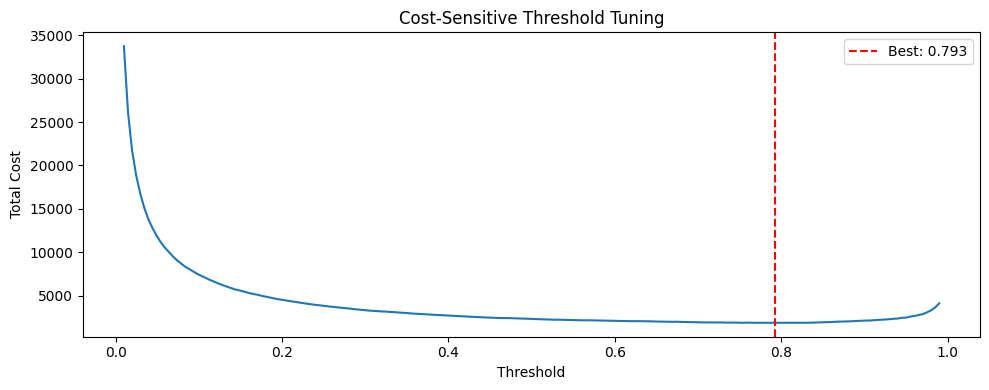

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix

thresholds = np.linspace(0.01, 0.99, 200)

COST_FP = 1
COST_FN = 6

losses = []

for t in thresholds:
    y_pred = (y_test_proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    total_loss = (fp * COST_FP) + (fn * COST_FN)
    losses.append(total_loss)

losses = np.array(losses)

best_idx = np.argmin(losses)
best_threshold = thresholds[best_idx]

print(f"Best threshold (cost-based): {best_threshold:.4f}")
print(f"Minimum expected loss: {losses[best_idx]}")

from sklearn.metrics import classification_report, precision_score, recall_score

y_pred_cost = (y_test_proba >= best_threshold).astype(int)

print("Precision:", precision_score(y_test, y_pred_cost))
print("Recall:", recall_score(y_test, y_pred_cost))
print("\nClassification Report:\n", classification_report(y_test, y_pred_cost))
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(thresholds, losses)
plt.axvline(best_threshold, color='red', linestyle='--', label=f'Best: {best_threshold:.3f}')
plt.xlabel('Threshold')
plt.ylabel('Total Cost')
plt.title('Cost-Sensitive Threshold Tuning')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
!git clone https://github.com/namebrandon/Sparkov_Data_Generation
%cd Sparkov_Data_Generation
!pip install faker

Cloning into 'Sparkov_Data_Generation'...
remote: Enumerating objects: 203, done.
remote: Counting objects: 100% (86/86), done.
remote: Compressing objects: 100% (32/32), done.
remote: Total 203 (delta 68), reused 54 (delta 54), pack-reused 117 (from 1)
Receiving objects: 100% (203/203), 1.12 MiB | 15.49 MiB/s, done.
Resolving deltas: 100% (107/107), done.
/content/Sparkov_Data_Generation/Sparkov_Data_Generation/Sparkov_Data_Generation


In [ ]:
!python datagen.py 01-01-2021 03-30-2021 -n 50 -o ./output

Num CPUs: 2
profile: adults_50up_male_urban.json, chunk size: 10,                 chunk: 0-9
profile: adults_50up_male_urban.json, chunk size: 10,                 chunk: 10-19
profile: adults_50up_male_urban.json, chunk size: 10,                 chunk: 20-29
profile: adults_50up_male_urban.json, chunk size: 10,                 chunk: 30-39
profile: adults_50up_male_urban.json, chunk size: 10,                 chunk: 40-49
profile: adults_50up_female_urban.json, chunk size: 10,                 chunk: 0-9
profile: adults_50up_female_urban.json, chunk size: 10,                 chunk: 10-19
profile: adults_50up_female_urban.json, chunk size: 10,                 chunk: 20-29
profile: adults_50up_female_urban.json, chunk size: 10,                 chunk: 30-39
profile: adults_50up_female_urban.json, chunk size: 10,                 chunk: 40-49
profile: adults_50up_male_rural.json, chunk size: 10,                 chunk: 0-9
profile: adults_50up_male_rural.json, chunk size: 10,                 c

In [ ]:
import glob
import pandas as pd

files = glob.glob('/content/Sparkov_Data_Generation/Sparkov_Data_Generation/Sparkov_Data_Generation/output/*.csv')
# Exclude customers.csv — it's not transaction data
files = [f for f in files if 'customers' not in f]

df_sparkov = pd.concat([pd.read_csv(f, sep='|') for f in files], ignore_index=True)
print(f"Shape: {df_sparkov.shape}")
print(f"Fraud rate: {df_sparkov['is_fraud'].mean():.4f} ({df_sparkov['is_fraud'].sum()} fraud cases)")
print(f"Date range: {df_sparkov['trans_date'].min()} to {df_sparkov['trans_date'].max()}")
print(f"Columns: {df_sparkov.columns.tolist()}")

Shape: (10513, 26)
Fraud rate: 0.0403 (424 fraud cases)
Date range: 2021-01-01 to 2021-03-30
Columns: ['ssn', 'cc_num', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat', 'long', 'city_pop', 'job', 'dob', 'acct_num', 'profile', 'trans_num', 'trans_date', 'trans_time', 'unix_time', 'category', 'amt', 'is_fraud', 'merchant', 'merch_lat', 'merch_long']


/tmp/ipython-input-2532139163.py:8: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_sparkov = pd.concat([pd.read_csv(f, sep='|') for f in files], ignore_index=True)


In [ ]:
# Combine trans_date and trans_time into single column to match your schema
df_sparkov['trans_date_trans_time'] = df_sparkov['trans_date'] + ' ' + df_sparkov['trans_time']
df_sparkov.insert(0, 'Unnamed: 0', range(len(df_sparkov)))
# Drop columns not in your schema
drop_cols = ['ssn', 'acct_num', 'profile', 'trans_date', 'trans_time']
df_sparkov = df_sparkov.drop(columns=[c for c in drop_cols if c in df_sparkov.columns])

print(df_sparkov.columns.tolist())
print(f"Shape: {df_sparkov.shape}")
print(f"Fraud rate: {df_sparkov['is_fraud'].mean():.4f} ({df_sparkov['is_fraud'].sum()} fraud cases)")
print(f"Date range: {df_sparkov['trans_date_trans_time'].min()} to {df_sparkov['trans_date_trans_time'].max()}")

['Unnamed: 0', 'cc_num', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'category', 'amt', 'is_fraud', 'merchant', 'merch_lat', 'merch_long', 'trans_date_trans_time']
Shape: (10513, 23)
Fraud rate: 0.0403 (424 fraud cases)
Date range: 2021-01-01 00:04:07 to 2021-03-30 23:50:11


In [ ]:
X_sparkov = df_sparkov.drop('is_fraud', axis=1)
y_sparkov = df_sparkov['is_fraud']
y_sparkov = df_sparkov['is_fraud'].astype(int)
X_sparkov_proc = preprocess_pipe.transform(X_sparkov)
sparkov_pool = Pool(X_sparkov_proc, cat_features=cat_cols)

y_sparkov_proba = cb_model.predict_proba(sparkov_pool)[:, 1]
print(f"Sparkov Test PR-AUC: {average_precision_score(y_sparkov, y_sparkov_proba):.4f}")

Sparkov Test PR-AUC: 0.7132


/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
